# Sentiment Analysis using RNN, LSTM and Word2Vec Embeddings

## Install Required Packages

In [ ]:
!pip install gensim
!pip install wordcloud contractions gradio


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 47.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 7.5 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Load Dataset

In [ ]:
import pandas as pd

train_df = pd.read_csv("/content/drive/MyDrive/AI and Machine Learning/Assessment_Part3/7. Racist Sexist or Not Dataset/train_racisit.csv")

print(train_df.head())

print("\nDataset Shape:", train_df.shape)

print("\nMissing Values:")
print(train_df.isnull().sum())


   id  label                                              tweet
0   1      0   @user when a father is dysfunctional and is s...
1   2      0  @user @user thanks for #lyft credit i can't us...
2   3      0                                bihday your majesty
3   4      0  #model   i love u take with u all the time in ...
4   5      0             factsguide: society now    #motivation

Dataset Shape: (31962, 3)

Missing Values:
id       0
label    0
tweet    0
dtype: int64


## Dataset Visualization

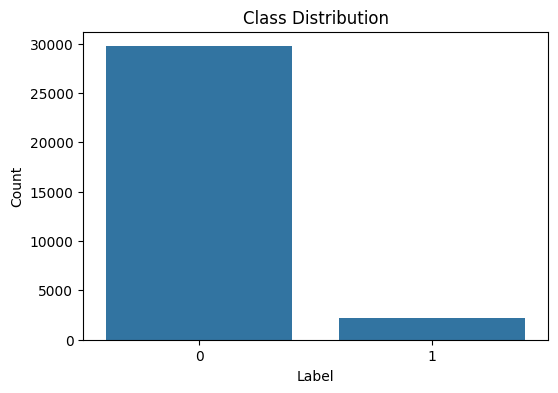

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

sns.countplot(x='label', data=train_df)

plt.title('Class Distribution')
plt.xlabel('Label')
plt.ylabel('Count')

plt.show()


## Text Cleaning Setup

In [ ]:
import re
import contractions
import nltk

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))

lemmatizer = WordNetLemmatizer()


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


## Text Cleaning Function

In [ ]:
def clean_text(text):

    text = text.lower()

    text = contractions.fix(text)

    text = re.sub(r'http\S+|www\S+', '', text)

    text = re.sub(r'@\w+', '', text)

    text = re.sub(r'#', '', text)

    text = re.sub(r'\d+', '', text)

    text = re.sub(r'[^a-zA-Z\s]', '', text)

    words = text.split()

    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return ' '.join(words)


## Apply Text Cleaning

In [ ]:
train_df['cleaned_tweet'] = train_df['tweet'].apply(clean_text)

train_df[['tweet', 'cleaned_tweet']].head()


,tweet,cleaned_tweet
0,@user when a father is dysfunctional and is s...,father dysfunctional selfish drag kid dysfunct...
1,@user @user thanks for #lyft credit i can't us...,thanks lyft credit cannot use offer wheelchair...
2,bihday your majesty,bihday majesty
3,#model i love u take with u all the time in ...,model love take time
4,factsguide: society now #motivation,factsguide society motivation


## Word Cloud Visualization

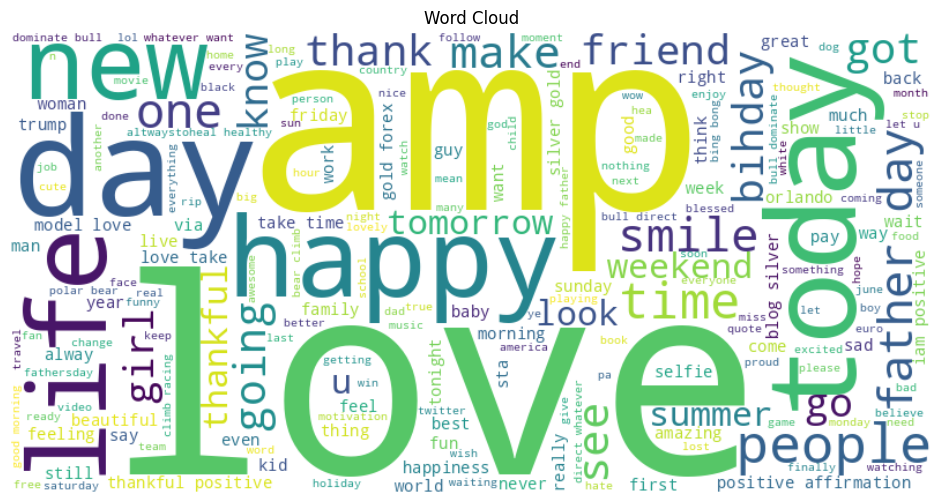

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

all_words = ' '.join(train_df['cleaned_tweet'])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(all_words)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud, interpolation='bilinear')

plt.axis('off')

plt.title('Word Cloud')

plt.show()


## Most Frequent Words

In [ ]:
from collections import Counter
import pandas as pd

words = all_words.split()

word_freq = Counter(words)

common_words = word_freq.most_common(20)

freq_df = pd.DataFrame(
    common_words,
    columns=['Word', 'Frequency']
)

freq_df


,Word,Frequency
0,day,2813
1,love,2796
2,happy,1691
3,amp,1608
4,time,1235
5,life,1235
6,like,1088
7,today,1086
8,get,1000
9,new,988


## Frequent Word Plot

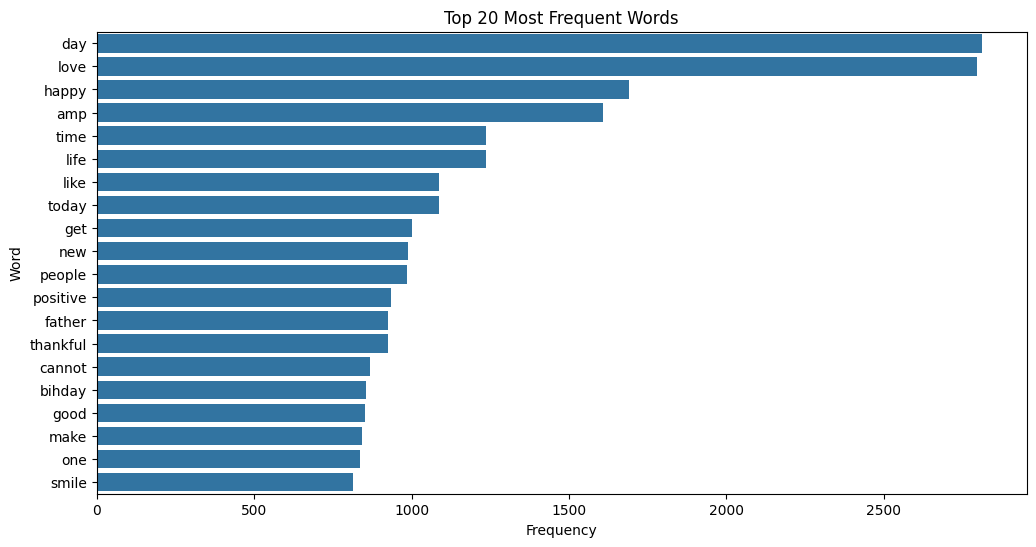

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

sns.barplot(
    x='Frequency',
    y='Word',
    data=freq_df
)

plt.title('Top 20 Most Frequent Words')

plt.show()


## Train Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X = train_df['cleaned_tweet']

y = train_df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))


Training Samples: 25569
Testing Samples: 6393


## Tokenizer

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer(
    num_words=10000,
    oov_token='<OOV>'
)

tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)

X_test_seq = tokenizer.texts_to_sequences(X_test)


## Padding Sequences

In [ ]:
import numpy as np

from tensorflow.keras.preprocessing.sequence import pad_sequences

sequence_lengths = [len(seq) for seq in X_train_seq]

max_len = int(np.percentile(sequence_lengths, 95))

print("Max Length:", max_len)

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=max_len,
    padding='post'
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=max_len,
    padding='post'
)

vocab_size = len(tokenizer.word_index) + 1

print("Vocabulary Size:", vocab_size)


Max Length: 13
Vocabulary Size: 32108


## Build Simple RNN Model

In [ ]:
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Embedding,
    SimpleRNN,
    Dense,
    Dropout
)

rnn_model = Sequential()

rnn_model.add(
    Embedding(
        input_dim=vocab_size,
        output_dim=128,
        input_length=max_len
    )
)

rnn_model.add(SimpleRNN(64))

rnn_model.add(Dropout(0.5))

rnn_model.add(Dense(1, activation='sigmoid'))

rnn_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

rnn_model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Train Simple RNN Model

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history_rnn = rnn_model.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=64,
    callbacks=[early_stop]
)


Epoch 1/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 19s 50ms/step - accuracy: 0.9448 - loss: 0.1859 - val_accuracy: 0.9521 - val_loss: 0.1536
Epoch 2/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 21s 50ms/step - accuracy: 0.9764 - loss: 0.0762 - val_accuracy: 0.9615 - val_loss: 0.1276
Epoch 3/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 16s 49ms/step - accuracy: 0.9915 - loss: 0.0311 - val_accuracy: 0.9599 - val_loss: 0.1748
Epoch 4/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 16s 49ms/step - accuracy: 0.9953 - loss: 0.0173 - val_accuracy: 0.9564 - val_loss: 0.1965
Epoch 5/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 22s 53ms/step - accuracy: 0.9969 - loss: 0.0123 - val_accuracy: 0.9574 - val_loss: 0.2086


## Build LSTM Model

In [ ]:
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Embedding,
    LSTM,
    Dense,
    Dropout
)

lstm_model = Sequential()

lstm_model.add(
    Embedding(
        input_dim=vocab_size,
        output_dim=128,
        input_length=max_len
    )
)

lstm_model.add(LSTM(64))

lstm_model.add(Dropout(0.5))

lstm_model.add(Dense(1, activation='sigmoid'))

lstm_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

lstm_model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Train LSTM Model

In [ ]:
history_lstm = lstm_model.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=64,
    callbacks=[early_stop]
)


Epoch 1/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 23s 61ms/step - accuracy: 0.9455 - loss: 0.1871 - val_accuracy: 0.9578 - val_loss: 0.1302
Epoch 2/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 19s 56ms/step - accuracy: 0.9748 - loss: 0.0784 - val_accuracy: 0.9630 - val_loss: 0.1193
Epoch 3/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 18s 56ms/step - accuracy: 0.9851 - loss: 0.0485 - val_accuracy: 0.9593 - val_loss: 0.1504
Epoch 4/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 18s 56ms/step - accuracy: 0.9907 - loss: 0.0334 - val_accuracy: 0.9578 - val_loss: 0.1800
Epoch 5/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 21s 57ms/step - accuracy: 0.9936 - loss: 0.0240 - val_accuracy: 0.9546 - val_loss: 0.1709


## Load Word2Vec Model

In [ ]:
import gensim.downloader as api

embedding_model = api.load(
    'glove-wiki-gigaword-50'
)


[==================================================] 100.0% 66.0/66.0MB downloaded


## Create Embedding Matrix

In [ ]:
import numpy as np

embedding_dim = 50

embedding_matrix = np.zeros(
    (vocab_size, embedding_dim)
)

for word, i in tokenizer.word_index.items():

    if i < vocab_size:

        try:
            embedding_vector = embedding_model[word]

            embedding_matrix[i] = embedding_vector

        except:
            pass


## Build Word2Vec LSTM

In [ ]:
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Embedding,
    LSTM,
    Dense,
    Dropout
)

word2vec_model = Sequential()

word2vec_model.add(
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        input_length=max_len,
        trainable=False
    )
)

word2vec_model.add(LSTM(64))

word2vec_model.add(Dropout(0.5))

word2vec_model.add(Dense(1, activation='sigmoid'))

word2vec_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

word2vec_model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │     1,605,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,605,400 (6.12 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,605,400 (6.12 MB)

## Train Word2Vec LSTM

In [ ]:
history_word2vec = word2vec_model.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=64,
    callbacks=[early_stop]
)


Epoch 1/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 12s 20ms/step - accuracy: 0.9356 - loss: 0.2096 - val_accuracy: 0.9368 - val_loss: 0.1719
Epoch 2/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.9446 - loss: 0.1612 - val_accuracy: 0.9402 - val_loss: 0.1594
Epoch 3/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.9479 - loss: 0.1481 - val_accuracy: 0.9439 - val_loss: 0.1530


## Plot RNN Accuracy

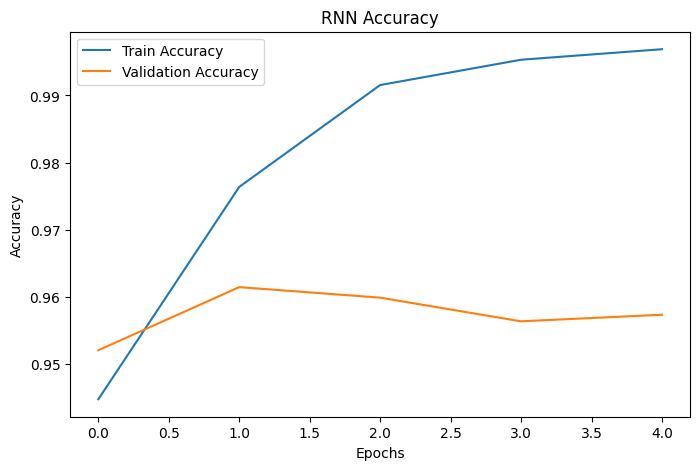

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    history_rnn.history['accuracy'],
    label='Train Accuracy'
)

plt.plot(
    history_rnn.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title('RNN Accuracy')

plt.xlabel('Epochs')

plt.ylabel('Accuracy')

plt.legend()

plt.show()


## Evaluation Function

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_model(model, X_test, y_test, model_name):

    predictions = model.predict(X_test)

    predictions = (predictions > 0.5).astype(int)

    accuracy = accuracy_score(y_test, predictions)

    print(f"\n{model_name} Accuracy:", accuracy)

    print("\nClassification Report:\n")

    print(classification_report(y_test, predictions))

    cm = confusion_matrix(y_test, predictions)

    plt.figure(figsize=(5,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )

    plt.title(f'{model_name} Confusion Matrix')

    plt.xlabel('Predicted')

    plt.ylabel('Actual')

    plt.show()


## Evaluate Models

200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

Simple RNN Accuracy: 0.9585484123259815

Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.99      0.98      5945
           1       0.81      0.53      0.64       448

    accuracy                           0.96      6393
   macro avg       0.89      0.76      0.81      6393
weighted avg       0.95      0.96      0.95      6393



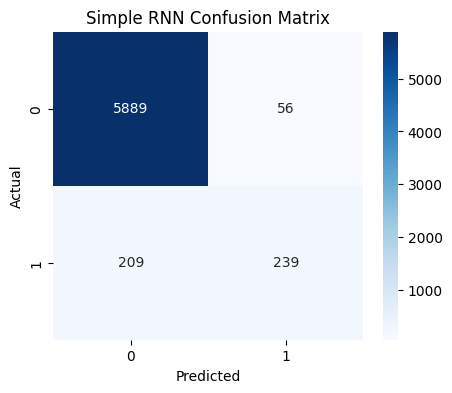

200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

LSTM Accuracy: 0.9638667292351009

Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.99      0.98      5945
           1       0.82      0.62      0.71       448

    accuracy                           0.96      6393
   macro avg       0.90      0.81      0.84      6393
weighted avg       0.96      0.96      0.96      6393



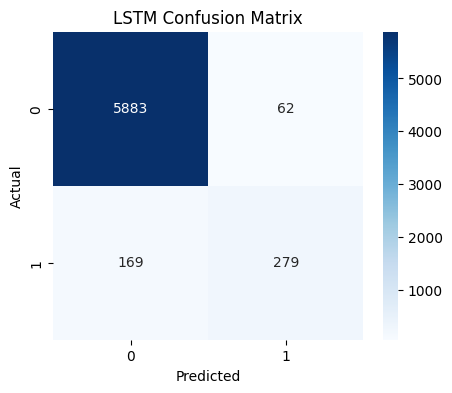

200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

Word2Vec LSTM Accuracy: 0.9413420929141249

Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.98      0.97      5945
           1       0.64      0.37      0.47       448

    accuracy                           0.94      6393
   macro avg       0.80      0.68      0.72      6393
weighted avg       0.93      0.94      0.93      6393



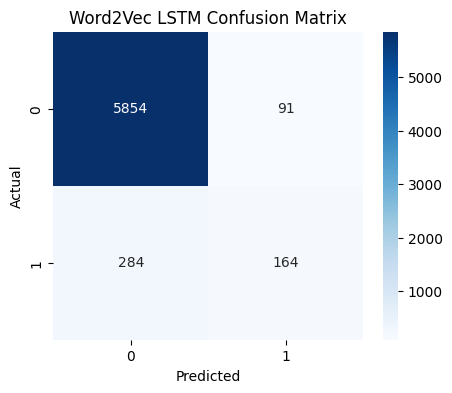

In [ ]:
evaluate_model(
    rnn_model,
    X_test_pad,
    y_test,
    'Simple RNN'
)

evaluate_model(
    lstm_model,
    X_test_pad,
    y_test,
    'LSTM'
)

evaluate_model(
    word2vec_model,
    X_test_pad,
    y_test,
    'Word2Vec LSTM'
)


## Gradio Interface

In [ ]:
import gradio as gr

from tensorflow.keras.preprocessing.sequence import pad_sequences

def predict_sentiment(text):

    cleaned = clean_text(text)

    seq = tokenizer.texts_to_sequences([cleaned])

    padded = pad_sequences(
        seq,
        maxlen=max_len,
        padding='post'
    )

    prediction = lstm_model.predict(padded)[0][0]

    if prediction > 0.5:
        return 'Hate / Racist-Sexist Tweet'

    else:
        return 'Non-Hate Tweet'

interface = gr.Interface(
    fn=predict_sentiment,

    inputs=gr.Textbox(
        lines=3,
        placeholder='Enter Tweet Here...'
    ),

    outputs='text',

    title='Tweet Sentiment Classifier'
)

interface.launch()


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://f04268dc092def2c9d.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
